In [68]:
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv('OpenAlexData.csv', index_col=0)

C:\Users\wieke\AppData\Local\Temp\ipykernel_16892\2055085896.py:1: DtypeWarning: Columns (8,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('OpenAlexData.csv', index_col=0)


In [70]:
pd.set_option("display.max_columns", 55)


In [71]:
def counts(col1, col2, col3, df):
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col3] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]
    oa_count_s
    return oa_count_s.sort_values(by=[col3], ascending=False)
    



In [72]:
def multiple_counts(col1, col2, col3, col4, df):
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col4] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]

    
    return oa_count_s


In [73]:
def oa_status(df, col1, col2, sorted):
    oa_status_df = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_status_df = oa_status_df.fillna(0)
    oa_status_df['total'] = oa_status_df['bronze'] + oa_status_df['closed'] + oa_status_df['gold'] + oa_status_df['green'] + oa_status_df['hybrid']
    oa_status_df['hybrid %'] = oa_status_df['hybrid'] / oa_status_df['total']
    oa_status_df['green %'] = oa_status_df['green'] / oa_status_df['total']
    oa_status_df['gold %'] = oa_status_df['gold'] / oa_status_df['total']
    oa_status_df['closed %'] = oa_status_df['closed'] / oa_status_df['total']
    oa_status_df['bronze %'] = oa_status_df['bronze'] / oa_status_df['total']
    dct = {'hybrid %': 'hybrid', 'green %': 'green', 'gold %': 'gold', 'closed %': 'closed', 'bronze %': 'bronze'}
    oa_status_df['Most used OA type'] = oa_status_df[['hybrid %', 'green %', 'gold %', 'closed %', 'bronze %']].idxmax(axis=1).map(dct)

    #oa_status_df = oa_status_df.sort_values(by=[sort], ascending=False)
    oa_status_df = oa_status_df.sort_values(by=[sorted], ascending=False).reset_index(drop=True)

    return oa_status_df

In [74]:
df.head()

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
0,https://openalex.org/W213417050,https://doi.org/10.1037/e675542012-001,dataset,funder,Cognitive Therapy for Depression,2012,2012-01-01,en,https://openalex.org/T11071,Treatment of Major Depression,https://openalex.org/subfields/2736,Pharmacology,https://openalex.org/fields/27,Medicine,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5059319052,Aaron T. Beck,last,https://orcid.org/0000-0001-6210-9528,https://openalex.org/I79576946,University of Pennsylvania,"Psychology,University of Pennsylvania",US,https://ror.org/00b30xv10,https://openalex.org/I79576946
1,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5025339678,John W. Creswell,first,https://orcid.org/0000-0002-5006-880X,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
2,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5021840711,Vicki L. Plano Clark,middle,https://orcid.org/0000-0002-9709-7982,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
3,https://openalex.org/W1639235375,https://doi.org/10.1037/e671332011-001,dataset,funder,The Loss of Sadness: How Psychiatry Transforme...,2009,2009-01-01,en,https://openalex.org/T12308,Mental Health and Psychiatry,https://openalex.org/subfields/1211,Philosophy,https://openalex.org/fields/12,Arts and Humanities,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5091505956,Jerome C. Wakefield,last,https://orcid.org/0000-0002-6809-5515,https://openalex.org/I57206974,New York University,"New York University, New York, NY, US",US,https://ror.org/0190ak572,https://openalex.org/I57206974
4,https://openalex.org/W2995669665,https://doi.org/10.1037/e555342011-003,dataset,funder,Cognitive Therapy for Depression,1996,1996-01-01,en,https://openalex.org/T13272,Psychological Treatments and Assessments,https://openalex.org/subfields/3203,Clinical Psychology,https://openalex.org/fields/32,Psychology,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5047792029,Aaron T. Beck,last,NaN,https://openalex.org/I79576946,University of Pennsylvania,"Department of Psychiatry, School of Medicine, ...",US,https://ror.org/00b30xv10,https://openalex.org/I79576946


In [75]:
df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        435461
Harvard Dataverse                                                                       30117
Zenodo (CERN European Organization for Nuclear Research)                                16798
Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature            16336
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)     13256
Figshare                                                                                 2976
IUPAC Standards Online                                                                    915
Default Digital Object Group                                                              579
PsycEXTRA Dataset                                                                         370
Authorea                                                                                  102
Artifact Digital Object Group                    

In [76]:
# remove faculty opinions as it is not a dataset content
df= df[df['Repository'] != 'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature']

# remove encode if wanting to remove this scope
encode_removed_df = df[(df['Repository'] != 'ENCODE Datasets')]

In [77]:
Michigan_df = df[df['institution_name'] == 'University of Michigan–Ann Arbor']
#ror_df = unnested_df[(unnested_df['ror'] == 'https://ror.org/0190ak572')]
Michigan_df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        434717
Harvard Dataverse                                                                        9034
Zenodo (CERN European Organization for Nuclear Research)                                 1422
Figshare                                                                                  554
IUPAC Standards Online                                                                    145
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)        72
Default Digital Object Group                                                               60
PsycEXTRA Dataset                                                                          59
Pancreapedia: The Exocrine Pancreas Knowledge Base                                         51
AEA Randomized Controlled Trials                                                           25
Authorea                                         

In [78]:
Michigan_df.groupby(['Repository', 'publication_year']).size().sort_values(ascending=False).head(15)


Repository                                                publication_year
ENCODE Datasets                                           2022                434618
Harvard Dataverse                                         2020                  3823
                                                          2019                  3565
                                                          2012                   584
Zenodo (CERN European Organization for Nuclear Research)  2023                   429
                                                          2021                   370
Figshare                                                  2023                   363
Harvard Dataverse                                         2018                   257
Zenodo (CERN European Organization for Nuclear Research)  2022                   244
                                                          2020                   190
Harvard Dataverse                                         2017             

In [79]:
encode_test = df[(df['Repository'] == 'ENCODE Datasets')]
len(encode_test) 

435461

In [80]:
df2022 = df[df['publication_year'] >= 2022]
df2021 = df[df['publication_year'] <= 2021]

In [81]:
institutions_df = counts('institution_name', 'is_oa', 'OA %', df).reset_index(drop=True)
institutions_df

is_oa,institution_name,False,True,OA %,Total
0,University of Michigan–Ann Arbor,998,445209,0.997763,446207
1,University of Pennsylvania,69,1881,0.964615,1950
2,Princeton University,219,5568,0.962157,5787
3,New York University,305,4105,0.930839,4410
4,University of Colorado Boulder,95,855,0.900000,950
5,University of Virginia,216,1781,0.891838,1997
6,Virginia Tech,120,891,0.881306,1011
7,Pennsylvania State University,448,3098,0.873660,3546
8,Michael J. Fox Foundation,1,5,0.833333,6
9,University of Illinois Urbana-Champaign,354,1639,0.822378,1993


In [82]:
institutions_2022df = counts('institution_name', 'is_oa', 'OA %', df2022).reset_index(drop=True)
institutions_2022df 

is_oa,institution_name,False,True,OA %,Total
0,University of Michigan–Ann Arbor,711,435365,0.998370,436076
1,University of Virginia,26,448,0.945148,474
2,University of Pennsylvania,26,230,0.898438,256
3,New York University,83,726,0.897404,809
4,Virginia Tech,59,494,0.893309,553
5,University of Colorado Boulder,21,152,0.878613,173
6,Princeton University,141,843,0.856707,984
7,Michael J. Fox Foundation,1,5,0.833333,6
8,University of New Mexico,6,28,0.823529,34
9,Pennsylvania State University,191,796,0.806484,987


In [83]:
institutions_2021df = counts('institution_name', 'is_oa', 'OA %', df2021).reset_index(drop=True)
institutions_2021df 

is_oa,institution_name,False,True,OA %,Total
0,Princeton University,78,4725,0.983760,4803
1,University of Pennsylvania,43,1651,0.974616,1694
2,University of Michigan–Ann Arbor,287,9844,0.971671,10131
3,Cornell University,261,6837,0.963229,7098
4,New York University,222,3379,0.938350,3601
5,University of Colorado Boulder,74,703,0.904762,777
6,Pennsylvania State University,257,2302,0.899570,2559
7,University of Virginia,190,1333,0.875246,1523
8,Virginia Tech,61,397,0.866812,458
9,Washington University in St. Louis,284,1848,0.866792,2132


<Axes: title={'center': 'Comparing OA % Across Institutions from before 2022 and 2022 Beyond'}, ylabel='institution_name'>

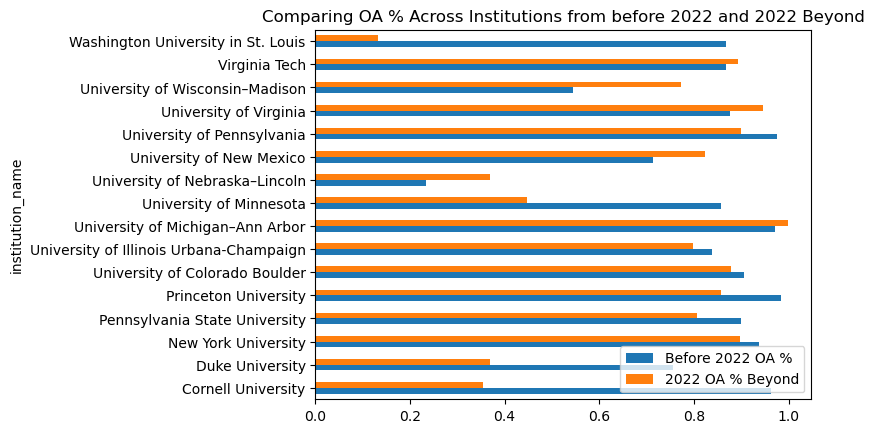

In [84]:
oa_df1 = counts('institution_name', 'is_oa', 'OA %', df2021).sort_values('institution_name', ascending=True)
oa_df2 = counts('institution_name', 'is_oa', 'OA %', df2022).sort_values('institution_name', ascending=True)
oa_df2 = oa_df2[oa_df2['institution_name'] != 'Michael J. Fox Foundation']

oa_df1 = oa_df1.rename(columns={'OA %': 'Before 2022 OA %'})
oa_df2 = oa_df2.rename(columns={'OA %': '2022 OA % Beyond'})

oa_df2 = oa_df2.reset_index(drop=True)
oa_df1 = pd.concat([oa_df1, oa_df2['2022 OA % Beyond']], axis=1)


# plotting sorted  by 2020 Diff 2018 on all there subjects (largest to smallest change)

oa_df_plot = oa_df1.plot(x="institution_name", y=['Before 2022 OA %', '2022 OA % Beyond'], kind="barh") 
oa_df_plot.set_title('Comparing OA % Across Institutions from before 2022 and 2022 Beyond')

oa_df_plot

In [85]:
MN_df = df[df['institution_name'] == 'University of Minnesota']
MN_2022df = df2022[df2022['institution_name'] == 'University of Minnesota']
MN_2021df = df2021[df2021['institution_name'] == 'University of Minnesota']


In [158]:
rads_df = pd.read_csv('RADS_Datasets_MN.csv')
rads_df.head()


,institution,id,type,DOI,publisher,container_type,container_title,container_volume,container_firstPage,container_identifier,container_identifierType,container_lastPage,publicationYear,language,ris,bibtex,citeproc,schemaOrg,resourceType,resourceTypeGeneral,version,URL,metadataVersion,schemaVersion,source,isActive,state,...,downloadCount,referenceCount,citationCount,partCount,partOfCount,versionCount,versionOfCount,created,registered,published,updated,data_id,data_type,container_issue,group,member,reference-count,title,created.date-parts2,created.date-parts3,created.date-time,created.timestamp,name,doi,url,container.title,publisher_plus
0,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25.000Z,2011-08-26T16:27:25.000Z,2015.0,2020-07-28T04:29:43.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,10.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,16.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25Z,2011-08-26T16:27:25Z,NaN,2022-06-01T22:50:13Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,4.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,15.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08.000Z,2011-11-29T19:14:08.000Z,2016.0,2020-07-28T04:32:35.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,31.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08Z,2011-11-29T19:14:08Z,NaN,2022-06-01T22:29:52Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Minnesota,10.5061/dryad.rk5fp6n9,dois,10.5061/dryad.rk5fp6n9,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012,en,DATA,misc,dataset,Dataset,dataset,Dataset,1,http://datadryad.org/stash/dataset/doi:10.5061...,16.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,9.0,1.0,1.0,1.0,0.0,0.0,0.0,2012-01-05T21:18:31Z,2012-01-05T21:18:31Z,NaN,2022-05-31T22:46:15Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
len(rads_df)

4971

In [160]:
rads_df = rads_df[['institution', 'id', 'DOI', 'publisher', 'publicationYear', 'resourceTypeGeneral', 
                   'resourceType', 'schemaOrg', 'citeproc', 'source', 'state']]

rads_df = rads_df.rename(columns={'resourceType': 'subjectType'})
rads_df = rads_df.rename(columns={'publisher': 'Repository'})	
#rads_df = rads_df.replace({'Harvard Dataverse': 'Harvard dataverse'})
rads_df = rads_df.replace({'Zenodo': 'Zenodo (CERN European Organization for Nuclear Research)', 'figshare': 'Figshare'})


rads_df = rads_df.replace('dataset', 'Dataset')
rads_df.head()

,institution,id,DOI,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [161]:
rads_df['resourceTypeGeneral'].value_counts().head(10)

resourceTypeGeneral
Dataset    4971
Name: count, dtype: int64

In [162]:
rads_df['subjectType'].value_counts().head(10)

subjectType
Dataset                                876
Dataset/Paleoecological Sample Data    210
Experimental Data                       79
Field Study Data                        45
survey data                             37
Simulation Data                         31
Genomics Data                           29
Programming Software Code               24
Other Dataset                           22
Specialized Mix                         20
Name: count, dtype: int64

In [163]:
rads_df['citeproc'].value_counts().head(15)

citeproc
Dataset    2578
article       2
Name: count, dtype: int64

In [164]:
def RadsCounts(col1, col2, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [165]:
def RadsMultipleCounts(col1, col2, col3, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [166]:
rads_df

,institution,id,DOI,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
...,...,...,...,...,...,...,...,...,...,...,...
4966,Minnesota,10.13020/1jgd-h107,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4967,Minnesota,10.13020/x4rh-tv45,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4968,Minnesota,10.13020/q5jh-n325,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4969,Minnesota,10.13020/tsva-hn81,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN


In [167]:
RadsPublishersDF = RadsCounts('Repository', 'resourceTypeGeneral', rads_df, 'Dataset')
#Rads_df2 = pd.concat([Rads_df2, counts])
#RadsPublishersDF = RadsPublishersDF.head(20)
RadsPublishersDF

resourceTypeGeneral,Repository,Dataset
0,Faculty Opinions Ltd,1682
1,Data Repository for the University of Minnesot...,774
2,Harvard Dataverse,590
3,Dryad,528
4,Zenodo (CERN European Organization for Nuclear...,387
...,...,...
62,Global Carbon Project,1
63,Environmental System Science Data Infrastructu...,1
64,NSF Arctic Data Center,1
65,Environmental System Science Data Infrastructu...,1


In [169]:
Rads_df2 = RadsCounts('Repository', 'resourceTypeGeneral', rads_df, 'Dataset')
#Rads_df2 = pd.concat([Rads_df2, counts])
Rads_df2.head(20)

resourceTypeGeneral,Repository,Dataset
0,Faculty Opinions Ltd,1682
1,Data Repository for the University of Minnesot...,774
2,Harvard Dataverse,590
3,Dryad,528
4,Zenodo (CERN European Organization for Nuclear...,387
5,Figshare,231
6,Neotoma Paleoecological Database,210
7,Qualitative Data Repository,145
8,ICPSR - Interuniversity Consortium for Politic...,99
9,Taylor & Francis,52


In [170]:
#mn_year_plot = mn_year_df.plot(x="publication_year", y=[True, False,'OA %'], kind="bar")
#mn_year_plot.set_title('MN Datasets Publication Year OA')


In [171]:
MN_2021_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2021df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_2021_repo_df 

is_oa,Repository,False,True,OA %,Total
0,Default Digital Object Group,47.0,9.0,0.160714,56.0
1,OSTI OAI (U.S. Department of Energy Office of ...,26.0,0.0,0.000000,26.0
2,IUPAC Standards Online,6.0,26.0,0.812500,32.0
3,PMC,5.0,0.0,0.000000,5.0
4,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
5,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
6,Figshare,0.0,12.0,1.000000,12.0
7,Harvard Dataverse,0.0,362.0,1.000000,362.0
8,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,5.0,1.000000,5.0
9,Zenodo (CERN European Organization for Nuclear...,0.0,102.0,1.000000,102.0


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Pre 2022 Total Counts')

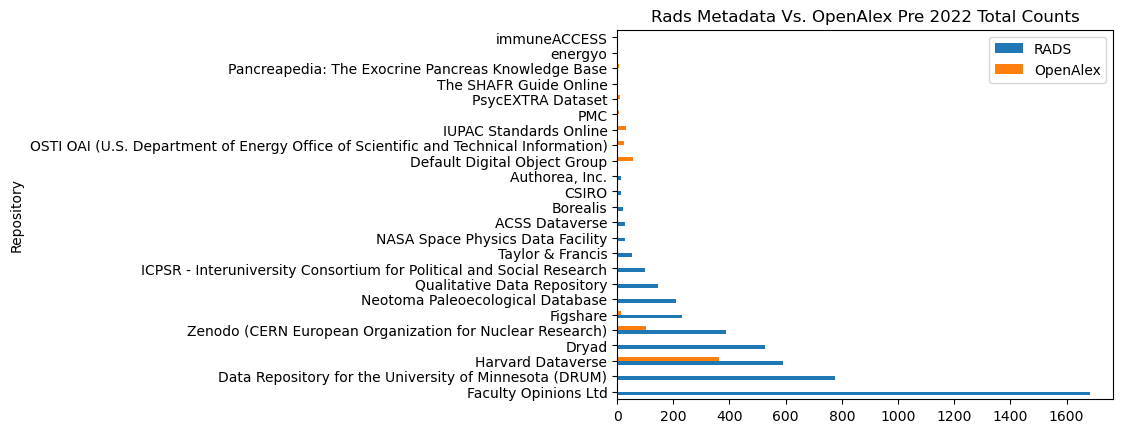

In [172]:
#merged.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh", stacked=True).set_title('Rads Metadata Vs. OpenAlex Pre 2022 Metadata')
Repo_comp_df = pd.merge(RadsPublishersDF.head(15), MN_2021_repo_df, on='Repository', how='outer')
Repo_comp_df = Repo_comp_df.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

Repo_comp_df.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Pre 2022 Total Counts')

#merged.set_title('Rads Dataset Vs. OpenAlex Pre 2022 Dataset')


In [206]:
RadsOA_df = RadsMultipleCounts('Repository', 'state', 'resourceTypeGeneral', rads_df, 'Dataset')
RadsOA_df
RadsOA_df = pd.merge(RadsPublishersDF, RadsOA_df, on='Repository', how='outer').head(20)
RadsOA_df = RadsOA_df.fillna(0)
#RadsOA_df['Total'] = RadsOA_df['Findable Datasets'] / RadsOA_df['Total Datasets']
RadsOA_df = RadsOA_df.rename(columns={'Dataset_x': 'Total Datasets'})
RadsOA_df = RadsOA_df.rename(columns={'Dataset_y': 'Findable Datasets'})
RadsOA_df['Findable %'] = RadsOA_df['Findable Datasets'] / RadsOA_df['Total Datasets']
RadsOA_df = RadsOA_df[['Repository', 'Total Datasets', 'Findable Datasets', 'Findable %']]

RadsOA_df


resourceTypeGeneral,Repository,Total Datasets,Findable Datasets,Findable %
0,Faculty Opinions Ltd,1682,0.0,0.000000
1,Data Repository for the University of Minnesot...,774,83.0,0.107235
2,Harvard Dataverse,590,590.0,1.000000
3,Dryad,528,528.0,1.000000
4,Zenodo (CERN European Organization for Nuclear...,387,387.0,1.000000
5,Figshare,231,231.0,1.000000
6,Neotoma Paleoecological Database,210,210.0,1.000000
7,Qualitative Data Repository,145,145.0,1.000000
8,ICPSR - Interuniversity Consortium for Politic...,99,99.0,1.000000
9,Taylor & Francis,52,52.0,1.000000


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Pre 2022 Total Counts')

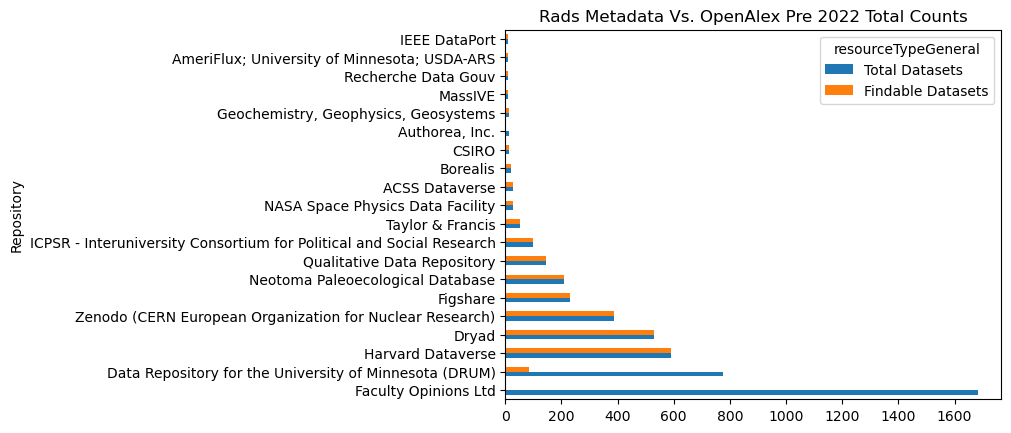

In [207]:
#Repo_comp_df = Repo_comp_df.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

RadsOA_df.plot(x="Repository", y=["Total Datasets", "Findable Datasets"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Pre 2022 Total Counts')

In [115]:
RadsSubjectsDF  = rads_df.groupby(['publisher'])['subjectType'].value_counts().reset_index().sort_values(by=['count'], ascending=False).reset_index(drop=True).head(20)
RadsSubjectsDF

,publisher,subjectType,count
0,Dryad,Dataset,528
1,Figshare,Dataset,231
2,Neotoma Paleoecological Database,Dataset/Paleoecological Sample Data,210
3,Data Repository for the University of Minnesot...,Experimental Data,79
4,Taylor & Francis,Dataset,52
5,Data Repository for the University of Minnesot...,Field Study Data,45
6,ICPSR - Interuniversity Consortium for Politic...,survey data,37
7,Data Repository for the University of Minnesot...,Simulation Data,31
8,Data Repository for the University of Minnesot...,Genomics Data,29
9,Data Repository for the University of Minnesot...,Programming Software Code,24


In [208]:
rads_df

,institution,id,DOI,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
...,...,...,...,...,...,...,...,...,...,...,...
4966,Minnesota,10.13020/1jgd-h107,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4967,Minnesota,10.13020/x4rh-tv45,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4968,Minnesota,10.13020/q5jh-n325,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN
4969,Minnesota,10.13020/tsva-hn81,NaN,Data Repository for the University of Minnesot...,2022,Dataset,NaN,NaN,NaN,NaN,NaN


In [101]:
MN_2022_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2022df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_2022_repo_df 

is_oa,Repository,False,True,OA %,Total
0,IUPAC Standards Online,214.0,0.0,0.000000,214.0
1,Zenodo (CERN European Organization for Nuclear...,23.0,120.0,0.839161,143.0
2,OSTI OAI (U.S. Department of Energy Office of ...,14.0,0.0,0.000000,14.0
3,Artifact Digital Object Group,4.0,0.0,0.000000,4.0
4,Default Digital Object Group,4.0,0.0,0.000000,4.0
5,Harvard Dataverse,0.0,90.0,1.000000,90.0


In [102]:
MN_field2021_df = multiple_counts('field_name', 'Repository', 'is_oa', 'OA %', MN_2021df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(10)
MN_field2021_df

is_oa,field_name,Repository,False,True,OA %,Total
0,Environmental Science,OSTI OAI (U.S. Department of Energy Office of ...,21.0,0.0,0.0,21.0
1,Engineering,Default Digital Object Group,15.0,0.0,0.0,15.0
2,Agricultural and Biological Sciences,PMC,5.0,0.0,0.0,5.0
3,"Biochemistry, Genetics and Molecular Biology",OSTI OAI (U.S. Department of Energy Office of ...,5.0,0.0,0.0,5.0
4,Social Sciences,The SHAFR Guide Online,2.0,0.0,0.0,2.0
5,Materials Science,Default Digital Object Group,2.0,0.0,0.0,2.0
6,"Biochemistry, Genetics and Molecular Biology",PsycEXTRA Dataset,1.0,0.0,0.0,1.0
7,Chemistry,IUPAC Standards Online,1.0,1.0,0.5,2.0
8,Physics and Astronomy,Default Digital Object Group,1.0,0.0,0.0,1.0
9,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,1.0,1.0,0.5,2.0


In [103]:
MN_field2022_df = multiple_counts('field_name', 'Repository', 'is_oa', 'OA %', MN_2022df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(20)
MN_field2022_df['Total'] = MN_field2022_df[True] + MN_field2022_df[False]

MN_field2022_df

is_oa,field_name,Repository,False,True,OA %,Total
0,Computer Science,IUPAC Standards Online,109.0,0.0,0.000000,109.0
1,"Pharmacology, Toxicology and Pharmaceutics",IUPAC Standards Online,34.0,0.0,0.000000,34.0
2,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,33.0,0.0,0.000000,33.0
3,Medicine,IUPAC Standards Online,20.0,0.0,0.000000,20.0
4,Chemistry,IUPAC Standards Online,11.0,0.0,0.000000,11.0
5,Environmental Science,OSTI OAI (U.S. Department of Energy Office of ...,6.0,0.0,0.000000,6.0
6,Environmental Science,IUPAC Standards Online,5.0,0.0,0.000000,5.0
7,"Biochemistry, Genetics and Molecular Biology",Zenodo (CERN European Organization for Nuclear...,4.0,0.0,0.000000,4.0
8,Environmental Science,Zenodo (CERN European Organization for Nuclear...,4.0,4.0,0.500000,8.0
9,Engineering,Default Digital Object Group,4.0,0.0,0.000000,4.0


In [104]:
MN_subfield2022_df = multiple_counts('subfield_name', 'Repository', 'is_oa', 'OA %', MN_2022df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(25)
MN_subfield2022_df['Total'] = MN_subfield2022_df[True] + MN_subfield2022_df[False]

MN_subfield2022_df

is_oa,subfield_name,Repository,False,True,OA %,Total
0,Computational Theory and Mathematics,IUPAC Standards Online,109.0,0.0,0.000000,109.0
1,Pharmacology,IUPAC Standards Online,29.0,0.0,0.000000,29.0
2,Molecular Biology,IUPAC Standards Online,17.0,0.0,0.000000,17.0
3,Physiology,IUPAC Standards Online,11.0,0.0,0.000000,11.0
4,Physical and Theoretical Chemistry,IUPAC Standards Online,7.0,0.0,0.000000,7.0
5,Global and Planetary Change,OSTI OAI (U.S. Department of Energy Office of ...,6.0,0.0,0.000000,6.0
6,Pharmaceutical Science,IUPAC Standards Online,5.0,0.0,0.000000,5.0
7,Biochemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0
8,Clinical Biochemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0
9,Environmental Chemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0


In [105]:
MN_subfield2021_df = multiple_counts('subfield_name', 'Repository', 'is_oa', 'OA %', MN_2021df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(16)
MN_subfield2021_df

is_oa,subfield_name,Repository,False,True,OA %,Total
0,Environmental Engineering,OSTI OAI (U.S. Department of Energy Office of ...,11.0,0.0,0.00,11.0
1,Computational Mechanics,Default Digital Object Group,8.0,0.0,0.00,8.0
2,Water Science and Technology,OSTI OAI (U.S. Department of Energy Office of ...,7.0,0.0,0.00,7.0
3,Genetics,OSTI OAI (U.S. Department of Energy Office of ...,5.0,0.0,0.00,5.0
4,Food Science,PMC,5.0,0.0,0.00,5.0
5,Biomedical Engineering,Default Digital Object Group,5.0,0.0,0.00,5.0
6,Pollution,OSTI OAI (U.S. Department of Energy Office of ...,3.0,0.0,0.00,3.0
7,Materials Chemistry,Default Digital Object Group,2.0,0.0,0.00,2.0
8,Civil and Structural Engineering,Default Digital Object Group,2.0,0.0,0.00,2.0
9,Clinical Psychology,PsycEXTRA Dataset,1.0,3.0,0.75,4.0


In [106]:
MN_rawstrings_df = multiple_counts('raw_affiliation_strings', 'Repository', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(33)
MN_rawstrings_df.to_csv('raw_strings.csv')
MN_rawstrings_df

is_oa,raw_affiliation_strings,Repository,False,True,OA %,Total
0,"Department of Medicinal Chemistry, University ...",IUPAC Standards Online,214.0,0.0,0.000000,214.0
1,Department of Aerospace Engineering and Mechan...,Default Digital Object Group,28.0,0.0,0.000000,28.0
2,University of Minnesota - St. Paul,OSTI OAI (U.S. Department of Energy Office of ...,21.0,0.0,0.000000,21.0
3,"University of Minnesota, Saint Paul, MN (Unite...",OSTI OAI (U.S. Department of Energy Office of ...,11.0,0.0,0.000000,11.0
4,"Univ. of Minnesota, Minneapolis, MN (United St...",OSTI OAI (U.S. Department of Energy Office of ...,7.0,0.0,0.000000,7.0
5,"University of Minnesota, Minneapolis 14, Minn....",IUPAC Standards Online,6.0,25.0,0.806452,31.0
6,"University of Minnesota, College of Veterinary...",Zenodo (CERN European Organization for Nuclear...,4.0,0.0,0.000000,4.0
7,"Department of Ecology, Evolution and Behavior,...",Zenodo (CERN European Organization for Nuclear...,4.0,2.0,0.333333,6.0
8,"Department of Chemistry, University of Minneso...",Default Digital Object Group,4.0,0.0,0.000000,4.0
9,"Department of Mechanical Engineering, Universi...",Default Digital Object Group,4.0,0.0,0.000000,4.0


In [107]:
MN_raw_authordf = multiple_counts('raw_affiliation_strings', 'author_name', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(20)
MN_raw_authordf

is_oa,raw_affiliation_strings,author_name,False,True,OA %,Total
0,"Department of Medicinal Chemistry, University ...",Phillip Portoghese,214.0,0.0,0.000000,214.0
1,Department of Aerospace Engineering and Mechan...,Ellen K. Longmire,13.0,0.0,0.000000,13.0
2,Department of Aerospace Engineering and Mechan...,Ankur Bordoloi,11.0,0.0,0.000000,11.0
3,"University of Minnesota, Minneapolis 14, Minn....",E. B. Sandell,6.0,25.0,0.806452,31.0
4,"Department of Mechanical Engineering, Universi...",Sharey Deep Guleria,4.0,0.0,0.000000,4.0
5,University of Minnesota - St. Paul,Timothy J. Griffis,4.0,0.0,0.000000,4.0
6,University of Minnesota - St. Paul,Matt Erickson,4.0,0.0,0.000000,4.0
7,University of Minnesota - St. Paul,Cody Winker,3.0,0.0,0.000000,3.0
8,"University of Minnesota, Saint Paul, MN (Unite...",Zachary W. Buell,3.0,0.0,0.000000,3.0
9,"Department of Ecology, Evolution and Behavior,...",Michael Travisano,2.0,0.0,0.000000,2.0


<Axes: ylabel='author_name'>

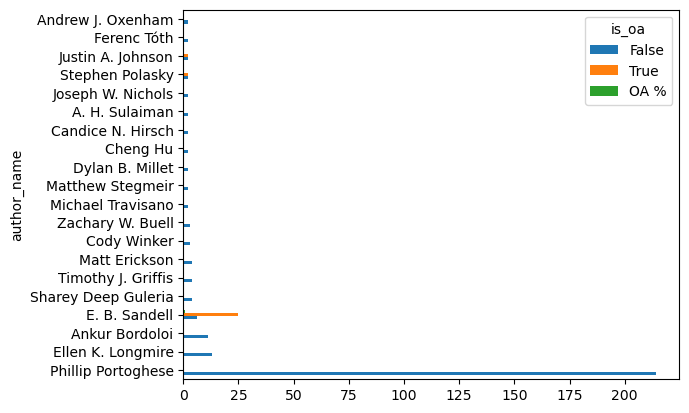

In [108]:
MN_raw_author_plot = MN_raw_authordf.plot(x="author_name", y=[False, True, 'OA %'], kind="barh")
MN_raw_author_plot

In [109]:
MN_field_authordf = multiple_counts('field_name', 'author_name', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(20)
MN_field_authordf

is_oa,field_name,author_name,False,True,OA %,Total
0,Computer Science,Phillip Portoghese,109.0,0.0,0.000000,109.0
1,"Pharmacology, Toxicology and Pharmaceutics",Phillip Portoghese,34.0,0.0,0.000000,34.0
2,"Biochemistry, Genetics and Molecular Biology",Phillip Portoghese,33.0,0.0,0.000000,33.0
3,Medicine,Phillip Portoghese,20.0,0.0,0.000000,20.0
4,Chemistry,Phillip Portoghese,11.0,0.0,0.000000,11.0
5,Engineering,Ellen K. Longmire,5.0,0.0,0.000000,5.0
6,Environmental Science,Phillip Portoghese,5.0,0.0,0.000000,5.0
7,Environmental Science,Matt Erickson,4.0,0.0,0.000000,4.0
8,Engineering,Ankur Bordoloi,4.0,0.0,0.000000,4.0
9,Engineering,Sharey Deep Guleria,4.0,0.0,0.000000,4.0


In [110]:
mn_year_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
mn_year_df

is_oa,institution_name,publication_year,False,True,OA %,Total
19,University of Minnesota,2024,16.0,5.0,0.238095,21.0
18,University of Minnesota,2023,14.0,57.0,0.802817,71.0
17,University of Minnesota,2022,229.0,148.0,0.392573,377.0
16,University of Minnesota,2021,0.0,53.0,1.000000,53.0
15,University of Minnesota,2020,10.0,144.0,0.935065,154.0
14,University of Minnesota,2019,8.0,104.0,0.928571,112.0
13,University of Minnesota,2018,5.0,105.0,0.954545,110.0
12,University of Minnesota,2017,6.0,8.0,0.571429,14.0
11,University of Minnesota,2016,10.0,29.0,0.743590,39.0
10,University of Minnesota,2015,0.0,4.0,1.000000,4.0


Text(0.5, 1.0, 'MN Datasets Publication Year OA')

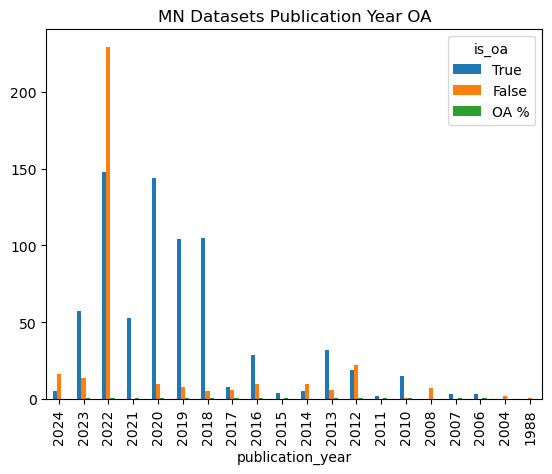

In [111]:
mn_year_plot = mn_year_df.plot(x="publication_year", y=[True, False,'OA %'], kind="bar")
mn_year_plot.set_title('MN Datasets Publication Year OA')

In [112]:
mn_status_df = oa_status(MN_df, 'publication_year', 'oa_status', 'publication_year')
mn_status_df

oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2024,0.0,16.0,5.0,0.0,0.0,21.0,0.000000,0.000000,0.238095,0.761905,0.000000,closed
1,2023,0.0,14.0,57.0,0.0,0.0,71.0,0.000000,0.000000,0.802817,0.197183,0.000000,gold
2,2022,0.0,229.0,148.0,0.0,0.0,377.0,0.000000,0.000000,0.392573,0.607427,0.000000,closed
3,2021,0.0,0.0,53.0,0.0,0.0,53.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold
4,2020,0.0,10.0,142.0,0.0,2.0,154.0,0.012987,0.000000,0.922078,0.064935,0.000000,gold
5,2019,0.0,8.0,104.0,0.0,0.0,112.0,0.000000,0.000000,0.928571,0.071429,0.000000,gold
6,2018,1.0,5.0,103.0,1.0,0.0,110.0,0.000000,0.009091,0.936364,0.045455,0.009091,gold
7,2017,6.0,6.0,2.0,0.0,0.0,14.0,0.000000,0.000000,0.142857,0.428571,0.428571,closed
8,2016,26.0,10.0,0.0,0.0,3.0,39.0,0.076923,0.000000,0.000000,0.256410,0.666667,bronze
9,2015,0.0,0.0,4.0,0.0,0.0,4.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold


<Axes: xlabel='publication_year'>

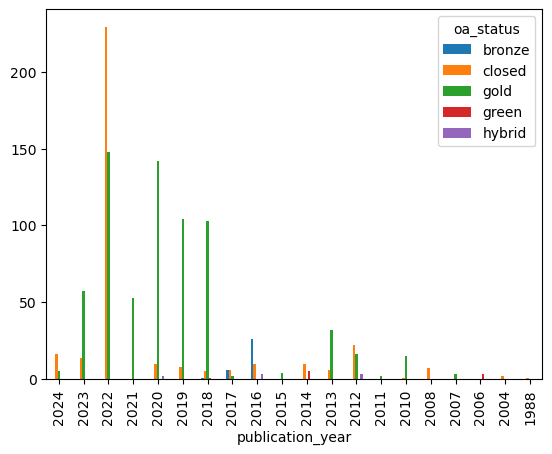

In [113]:
mn_status_plot = mn_status_df.plot(x="publication_year", y=["bronze", "closed", "gold", "green", "hybrid"], kind="bar")
mn_status_plot